## Define models

In [6]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.signal import square
from math import floor
from numba import njit



# Define the model WITH delays for lysis and for pili expression after plasmid acquisition
@njit
def model_w_delays(t, y, alpha, gamma_hi, gamma_lo, delta, qc, CP, b, delta_P, K, cost, pl, T_lysis, T_pili, N):
    y = y.reshape(5+2*N) #for some reason without this y = [y0,y1,...,yn] becomes y = [[y0],[y1],...,[yn]]
    k_hi = CP*gamma_hi
    k_lo = CP*gamma_lo
    B0 = y[0]
    BP_hi = y[1]
    BP_lo = y[2]
    P = y[3]
    Bc = y[4]
    i_Bi = slice(5,5+N)
    i_BPnp = slice(5 + N, 5+ 2*N)
    Bi = y[5:5+N]
    BPnp = y[5+N:5+2*N] #np for "no pili"
  
    C = 1 - (B0 + BP_hi + BP_lo + Bc + sum(Bi) + sum(BPnp))/K
    dB0dt =  alpha*C*(B0 + pl*(1+cost)*(BP_hi + BP_lo)) - gamma_hi*B0*BP_hi - gamma_lo*B0*BP_lo - delta*B0 
    dBP_hidt = alpha*(1 + cost)*C*(1 - pl)*BP_hi + (N/T_pili)*BPnp[-1]  - qc*BP_hi - k_hi*BP_hi*P - delta*BP_hi
    dBP_lodt = alpha*(1 + cost)*C*(1 - pl)*BP_lo + qc*BP_hi - k_lo*BP_lo*P - delta*BP_lo
   

    dBcdt = alpha*C*Bc- delta*Bc
    
    #calculate "vector" terms for lysis and pili expression intermediate states
    dPdt = b*(N/T_lysis)*Bi[-1] - delta_P*P - k_hi*sum(y[5:5+N])*P
    dBidt = np.zeros(len(Bi))
    dBidt[0] = k_hi*BP_hi*P + k_lo*BP_lo*P - (N/T_lysis)*Bi[0]- delta*Bi[0]
    for i in range(1, len(Bi)):
        dBidt[i] = (N/T_lysis)*(Bi[i-1] - Bi[i]) - delta*Bi[i]
        
    dBPnpdt = np.zeros(len(BPnp))
    dBPnpdt[0] = (gamma_hi*BP_hi + gamma_lo*BP_lo)*B0 -(N/T_pili)*BPnp[0] - delta*BPnp[0] 
    for i in range(1, len(BPnp)):
        dBPnpdt[i] = (N/T_pili)*(BPnp[i-1] - BPnp[i]) - delta*BPnp[i]
    
    result = np.empty_like(y)
    scalar_vars = [dB0dt, dBP_hidt, dBP_lodt, dPdt, dBcdt]
    result[i_scalars] = scalar_vars
    result[i_Bi] = dBidt
    result[i_BPnp] = dBPnpdt
    return result



## Define parameters

In [7]:
#parameters
alpha = 1.0        # Growth rate of the bacteria w/o the plasmid
gamma_hi =1*10**(-8)     # Conjugation rate (in ml/hour)
gamma_lo = 1*10**(-12)
CP = 1 #constant of proportionality between the congugation constant and the phage predation constant (due to pilus expression)
delta = 0.1     #Death rate of bacteria
qc = 0      #rate of pili repression (nonzero in last plot)
b = 10**2     # Burst size of phage
delta_P = 0.1      # Rate of background death of phage
K = 10**8  #carrying capacity
cost = -0.5 #growth cost of plasmid
pl = 0.001     # Probability of losing the plasmid



#Simulation parameters
tf = 10**4 #Time to be simulated (in hours)
tEq = 1000



## Simulate Figure 2B

In [8]:
#delay params
T_lysis = 0.5
T_pili = 0.5
N = 10
tf = 10**3


params = [alpha, gamma_hi, gamma_lo, delta, qc, CP, b, delta_P, K, cost, pl, T_lysis, T_pili, N]


# Initial condition
B00 = K
BP_hi0 =  K
BP_lo0 = 0
P0 = 0 #remove phage from this simulation
Bc0 = 0 #add competitor after equilibrium is reached
Bi0 = np.zeros(N) #vectors to store intermediate states in phage life cycle and conjugation cycle
BPnp0 = np.zeros(N)
scalar_vars0 = [B00, BP_hi0, BP_lo0, P0, Bc0]
y0 = np.empty(5+2*N)
i_scalars = slice(0,5)
i_Bi = slice(5,5+N)
i_BPnp = slice(5 + N, 5+ 2*N)
y0[i_scalars] = scalar_vars0
y0[i_Bi] = Bi0
y0[i_BPnp] = BPnp0


#run simulation without phage until equilibrium
###################################################

t0 = 0
solEq = solve_ivp(
        model_w_delays,
        [t0, tEq],
        y0,
        t_eval=np.arange(t0, tEq, 1.0),
        args = params,
        dense_output=False,
        vectorized = True,
        method='LSODA', 
        max_step=1.0 
    )


#Add competitor
#####################################
yEq = solEq.y[:, -1].copy()
y0 = yEq
y0[3] = 20
t0 = 0


#Define exctinction events (params are needed because solve_ivp always calls the event functions using them)
##################################################################################
def Bp_extinction_event(t, y, alpha, gamma_hi, gamma_lo, delta, qc, CP, b, delta_P, K, cost, pl, T_lysis, T_pili, N):
    return y[1] + y[2] - 1
Bp_extinction_event.terminal = True
Bp_extinction_event.direction = -1

def P_extinction_event(t, y, alpha, gamma_hi, gamma_lo, delta, qc, CP, b, delta_P, K, cost, pl, T_lysis, T_pili, N):
    return y[3] - 1
P_extinction_event.terminal = True
P_extinction_event.direction = -1

def Bc_extinction_event(t, y, alpha, gamma_hi, gamma_lo, delta, qc, CP, b, delta_P, K, cost, pl, T_lysis, T_pili, N):
    return y[4] - 1
Bc_extinction_event.terminal = True
Bc_extinction_event.direction = -1


extinction_events = [Bp_extinction_event, P_extinction_event, Bc_extinction_event]


#Run simulation loop that halts when extinction events are triggered and restarts with extinct populations set to zero
#####################################
t_all = []
y_all = []
t_span = [t0, tf]
t_eval = np.concatenate(([0], np.logspace(np.log(0.0001), np.log10(tf), 10**4)))
while t0 < tf:
    t_span = [t0,tf]
    t_eval = [t for t in t_eval if t >= t0]
    sol = solve_ivp(
        model_w_delays,
        t_span,
        y0,
        events=extinction_events,
        t_eval= t_eval,
        args = params,
        dense_output=False,
        method='LSODA', 
        max_step=10.0
    )




    # Store results
    t_all.extend(sol.t)
    y_all.extend(sol.y.T)
    # Check which event triggered
    triggered = [len(ev) > 0 for ev in sol.t_events]
    y0 = sol.y[:, -1].copy()


    if triggered[0]:  #plasmid extinction
        y0[1] = 0.0
        y0[2] = 0.0
        y0[i_BPnp] = np.zeros(N)
    if triggered[1]:  #phage extinction
        y0[3] = 0.0
    if triggered[2]:  #competitor extinction
        y0[4] = 0.0

    if not any(triggered):
        break  # no events, done
    else:
        t0 = sol.t[-1]




#store simulation output data
data3 = np.array(y_all)
t3 = t_all.copy()



## Simulate Figure 2D

In [9]:
#delay params
T_lysis = 0.5
T_pili = 0.5
N = 10
tf = 10**3

#add in transitory derepression
qcnew = 0.1

params = [alpha, gamma_hi, gamma_lo, delta, qcnew, CP, b, delta_P, K, cost, pl, T_lysis, T_pili, N]

k_hi = gamma_hi*CP
# Initial condition
#B00 = K
#BP_hi0 =  K
#BP_lo0 = 0
#P0 = 0 #remove phage from this simulation
#Bc0 = 0 #add competitor after equilibrium is reached
Bi0 = 0#delta_P/(N*k_hi)*np.ones(N) #vectors to store intermediate states in phage life cycle and conjugation cycle
BPnp0 = gamma_hi*K*T_pili/N*1/T_lysis*delta_P/k_hi*1/(gamma_hi*K - qcnew)*np.ones(N) #K*np.zeros(N)
B00 = K
BP_hi0 =  1/T_lysis*delta_P/k_hi*1/(gamma_hi*K - qcnew)
BP_lo0 = 0
P0 = 0#(gamma_hi*K-qcnew)/k_hi
scalar_vars0 = [B00, BP_hi0, BP_lo0, P0, Bc0]
y0 = np.empty(5+2*N)
i_scalars = slice(0,5)
i_Bi = slice(5,5+N)
i_BPnp = slice(5 + N, 5+ 2*N)
y0[i_scalars] = scalar_vars0
y0[i_Bi] = Bi0
y0[i_BPnp] = BPnp0


#run simulation without phage until equilibrium
###################################################

t0 = 0
tEq = 1000
solEq = solve_ivp(
        model_w_delays,
        [t0, tEq],
        y0,
        t_eval=np.arange(t0, tEq, 1.0),
        args = params,
        dense_output=False,
        method='LSODA', 
        max_step=1.0 
    )


#Add competitor
#####################################
yEq = solEq.y[:, -1].copy()
y0 = yEq
y0[3] = 20
t0 = 0



#Define exctinction events (params are needed because solve_ivp always calls the event functions using them)
##################################################################################
def Bp_extinction_event(t, y, alpha, gamma_hi, gamma_lo, delta, qc, CP, b, delta_P, K, cost, pl, T_lysis, T_pili, N):
    return y[1] + y[2] - 1
Bp_extinction_event.terminal = True
Bp_extinction_event.direction = -1

def P_extinction_event(t, y, alpha, gamma_hi, gamma_lo, delta, qc, CP, b, delta_P, K, cost, pl, T_lysis, T_pili, N):
    return y[3] - 1
P_extinction_event.terminal = True
P_extinction_event.direction = -1

def Bc_extinction_event(t, y, alpha, gamma_hi, gamma_lo, delta, qc, CP, b, delta_P, K, cost, pl, T_lysis, T_pili, N):
    return y[4] - 1
Bc_extinction_event.terminal = True
Bc_extinction_event.direction = -1


extinction_events = [Bp_extinction_event, P_extinction_event, Bc_extinction_event]


#Run simulation loop that halts when extinction events are triggered and restarts with extinct populations set to zero
#####################################
t_all = []
y_all = []
t_span = [t0, tf]
t_eval = np.concatenate(([0], np.logspace(np.log(0.0001), np.log10(tf), 10**4)))
while t0 < tf:
    t_span = [t0,tf]
    t_eval = [t for t in t_eval if t >= t0]
    sol = solve_ivp(
        model_w_delays,
        t_span,
        y0,
        events=extinction_events,
        t_eval= t_eval,
        args = params,
        dense_output=False,
        method='LSODA', 
        max_step=1.0
    )



    # Store results
    t_all.extend(sol.t)
    y_all.extend(sol.y.T)
    # Check which event triggered
    triggered = [len(ev) > 0 for ev in sol.t_events]
    y0 = sol.y[:, -1].copy()


    if triggered[0]:  #plasmid extinction
        print('plasmid extinct!')
        y0[1] = 0.0
        y0[2] = 0.0
        y0[i_BPnp] = np.zeros(N)

    if triggered[1]:  #phage extinction
        y0[3] = 0.0
    if triggered[2]:  #competitor extinction
        y0[4] = 0.0

    if not any(triggered):
        break  # no events, done
    else:
        t0 = sol.t[-1]



#store simulation output data
data4 = np.array(y_all)
t4 = t_all.copy()


## Make plots

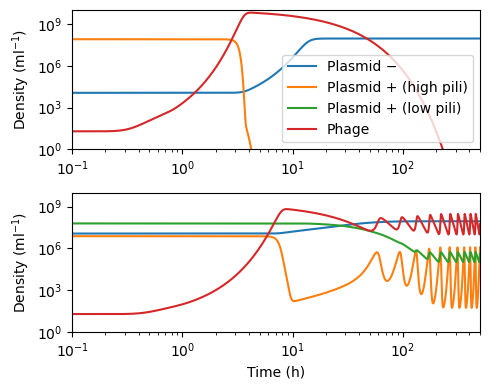

In [11]:
import matplotlib.pyplot as plt

datasets = [data3, data4]
times = [t3, t4]
labels = ['Plasmid −', 'Plasmid + (high pili)', 'Plasmid + (low pili)', 'Phage', '']
styles = ["-", "-", "-", "-", ":",'']

# Create three vertically stacked plots sharing x-axis
fig, axes = plt.subplots(nrows=2, sharex=False, figsize=(5, 4))
for ax, data, t in zip(axes, datasets, times):
    for y, style, label in zip(data.T, styles, labels):
        ax.plot(t, y, linestyle=style, label=label)
    ax.margins(x=0)  # no extra padding on the x-axis
    ax.set_ylim(1, 10**10)
    ax.set_xlim(0.1, 500)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylabel('Density (ml$^{-1}$)')
    ax.grid(False)

# Only the bottom plot gets the x-axis label
axes[-1].set_xlabel('Time (h)')


# Only the top plot gets the legend
axes[0].legend()

plt.tight_layout()
plt.savefig('Figure_2BD.svg', format = 'svg')